In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

In [2]:
file_path = "COM7_2026_03_16.21.40.01.788.txt"

df = pd.read_csv(file_path, header=None, names=["time_ms", "red", "ir"])
df.head()

,time_ms,red,ir
0,974748,121832,151226
1,974788,121783,151158
2,974828,121776,151227
3,974868,121814,151357
4,974908,121863,151487


In [3]:
df["time_s"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0
df.head()

,time_ms,red,ir,time_s
0,974748,121832,151226,0.00
1,974788,121783,151158,0.04
2,974828,121776,151227,0.08
3,974868,121814,151357,0.12
4,974908,121863,151487,0.16


In [4]:
dt = df["time_s"].diff().dropna()
fs = 1.0 / dt.mean()

print("Estimated sampling frequency (Hz):", fs)
print("Mean dt (s):", dt.mean())

Estimated sampling frequency (Hz): 24.993237760346226
Mean dt (s): 0.04001082251082251


In [5]:
signal = df["ir"].astype(float)

# nền chậm: cửa sổ 1 giây
baseline_window = int(fs * 1.0)
if baseline_window < 3:
    baseline_window = 3

baseline = signal.rolling(window=baseline_window, center=True).mean()

# AC xấp xỉ = tín hiệu - nền
signal_ac = signal - baseline

df["ir_baseline"] = baseline
df["ir_ac"] = signal_ac

In [6]:
smooth_window = int(fs * 0.08)   # khoảng 80 ms
if smooth_window < 3:
    smooth_window = 3
if smooth_window % 2 == 0:
    smooth_window += 1

signal_ac_smooth = df["ir_ac"].rolling(window=smooth_window, center=True).mean()
df["ir_ac_smooth"] = signal_ac_smooth

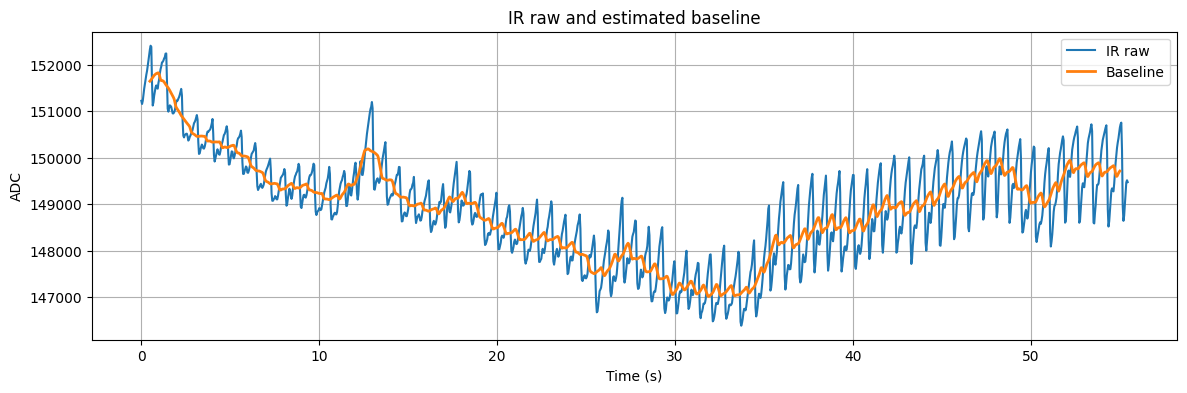

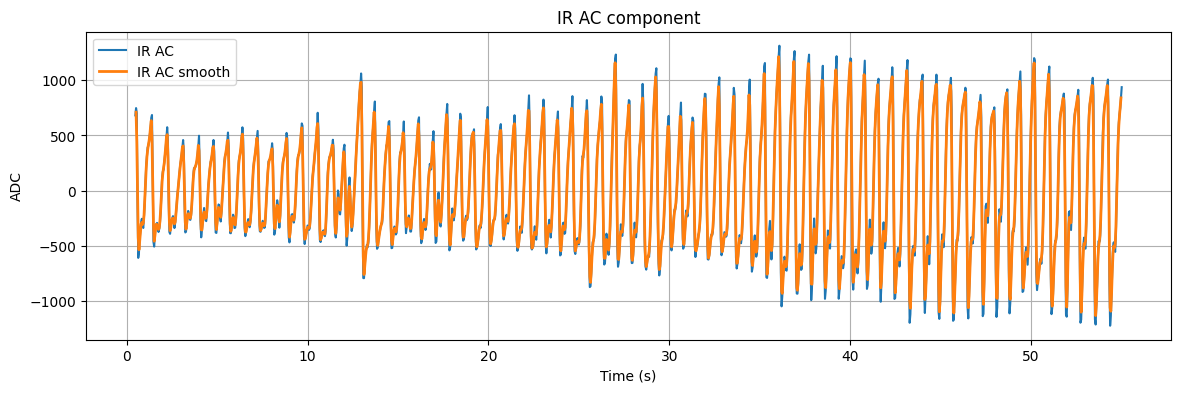

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["ir"], label="IR raw")
plt.plot(df["time_s"], df["ir_baseline"], label="Baseline", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("IR raw and estimated baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["ir_ac"], label="IR AC")
plt.plot(df["time_s"], df["ir_ac_smooth"], label="IR AC smooth", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("IR AC component")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
clean = df["ir_ac_smooth"].copy()

# bỏ NaN ở đầu/cuối do rolling
valid = clean.notna()
time_valid = df.loc[valid, "time_s"].to_numpy()
sig_valid = clean[valid].to_numpy()

# khoảng cách tối thiểu giữa 2 peak
# ví dụ không thể có nhịp tim > 180 bpm
# 180 bpm = 3 beat/s => khoảng cách tối thiểu ~ 0.33 s
min_distance_sec = 0.33
min_distance_samples = int(min_distance_sec * fs)

# prominence giúp bỏ peak yếu
prom = np.std(sig_valid) * 0.4

peaks, properties = find_peaks(
    sig_valid,
    distance=min_distance_samples,
    prominence=prom
)

peak_times = time_valid[peaks]
peak_values = sig_valid[peaks]

print("Number of peaks:", len(peaks))

Number of peaks: 69


In [9]:
peak_intervals = np.diff(peak_times)   # giây giữa các peak liên tiếp

if len(peak_intervals) > 0:
    mean_interval = peak_intervals.mean()
    bpm = 60.0 / mean_interval
    print("Estimated BPM:", bpm)
    print("Mean peak interval (s):", mean_interval)
else:
    bpm = np.nan
    print("Not enough peaks to estimate BPM")

Estimated BPM: 77.19231860751111
Mean peak interval (s): 0.7772794117647059


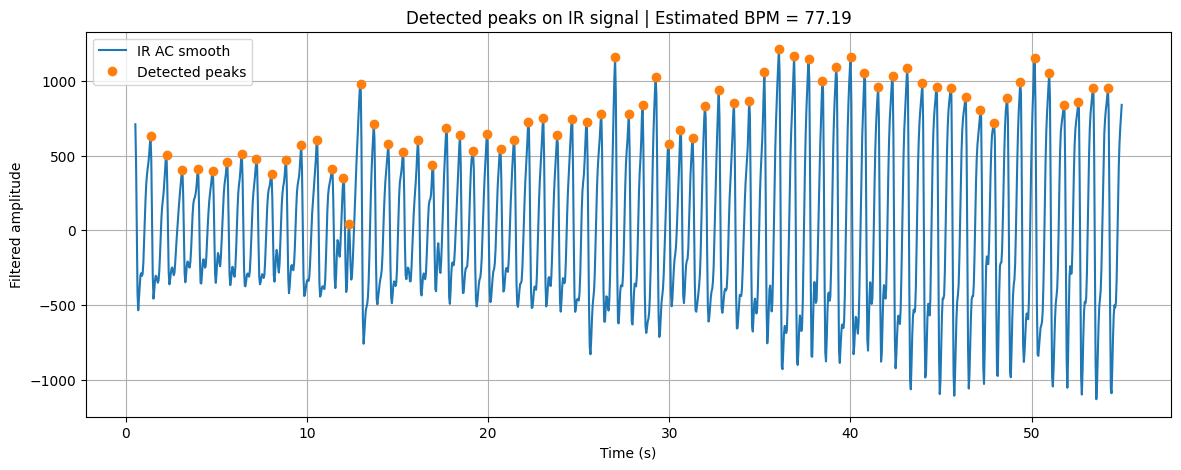

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(time_valid, sig_valid, label="IR AC smooth")
plt.plot(peak_times, peak_values, "o", label="Detected peaks")
plt.xlabel("Time (s)")
plt.ylabel("Filtered amplitude")
plt.title(f"Detected peaks on IR signal | Estimated BPM = {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()

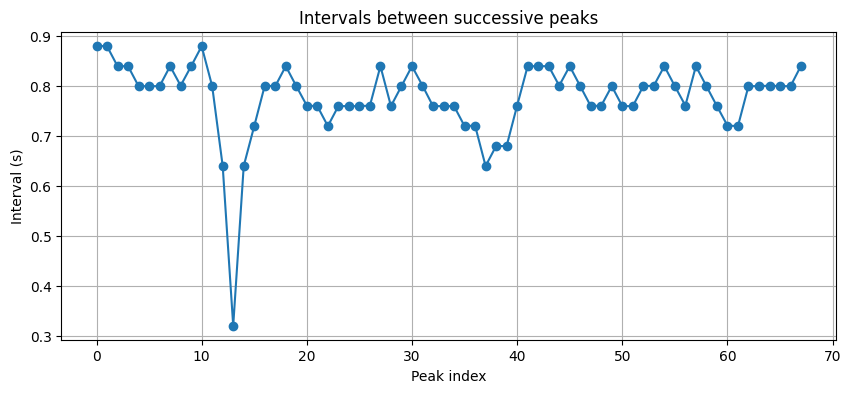

Min interval: 0.3199999999999985
Max interval: 0.881
Mean interval: 0.7772794117647059


In [11]:
if len(peak_intervals) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(peak_intervals, marker="o")
    plt.xlabel("Peak index")
    plt.ylabel("Interval (s)")
    plt.title("Intervals between successive peaks")
    plt.grid(True)
    plt.show()

    print("Min interval:", peak_intervals.min())
    print("Max interval:", peak_intervals.max())
    print("Mean interval:", peak_intervals.mean())

Estimated sampling frequency (Hz): 99.94431159301602


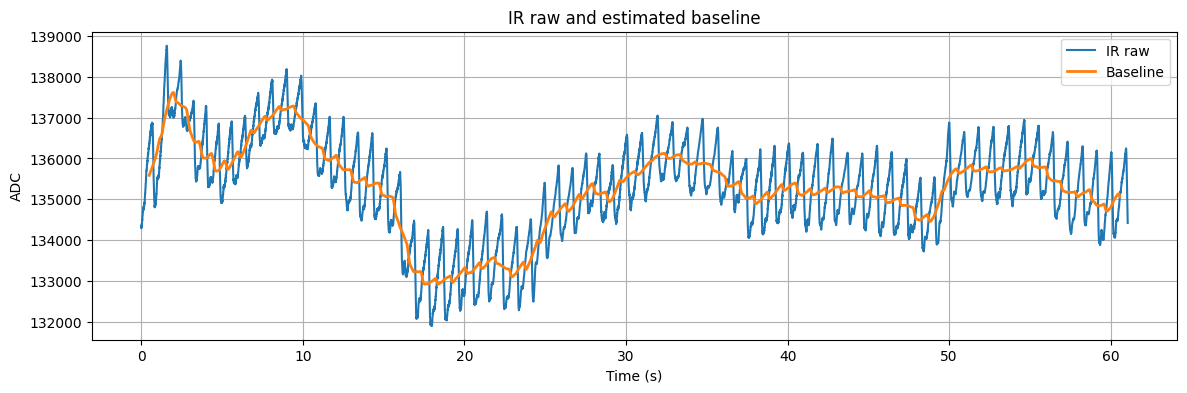

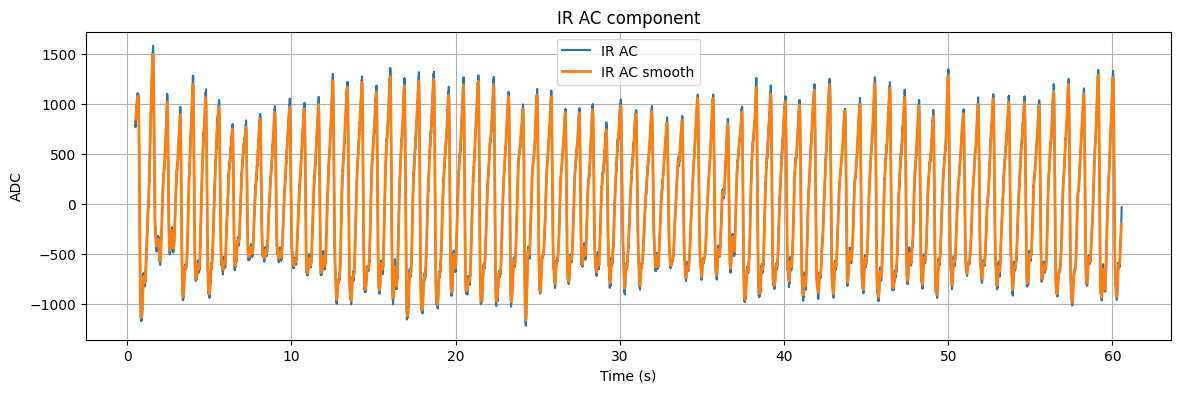

Number of peaks: 67
Estimated BPM: 67.72472294431523
Mean peak interval (s): 0.8859393939393939


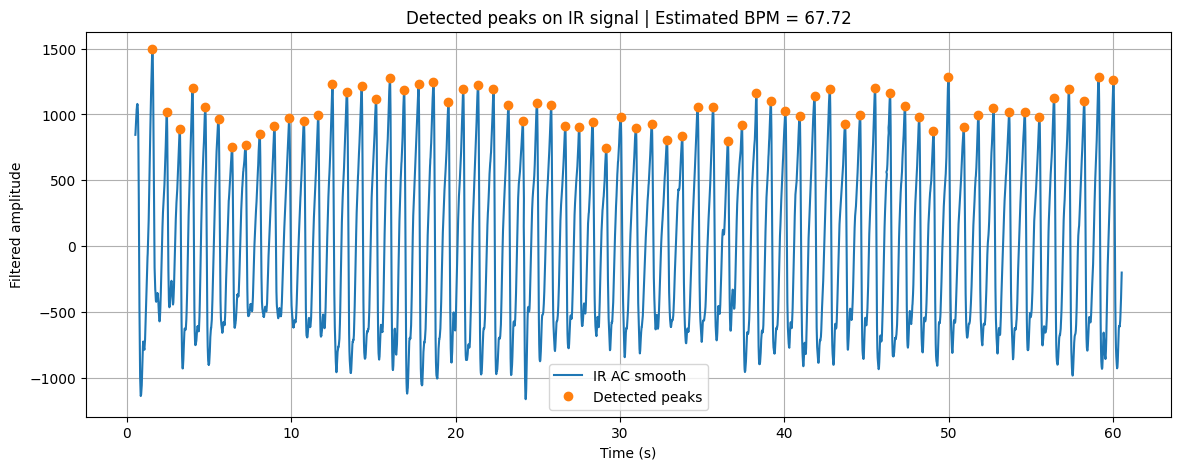

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

file_path = "max30102_sample_avg_1_60s.txt"

rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        parts = line.split(",")
        if len(parts) == 3:
            try:
                t = int(parts[0])
                red = int(parts[1])
                ir = int(parts[2])
                rows.append([t, red, ir])
            except ValueError:
                pass

df = pd.DataFrame(rows, columns=["time_ms", "red", "ir"])
df["time_s"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0

dt = df["time_s"].diff().dropna()
fs = 1.0 / dt.mean()
print("Estimated sampling frequency (Hz):", fs)

signal = df["ir"].astype(float)

baseline_window = int(fs * 1.0)
if baseline_window < 3:
    baseline_window = 3

df["ir_baseline"] = signal.rolling(window=baseline_window, center=True).mean()
df["ir_ac"] = signal - df["ir_baseline"]

smooth_window = int(fs * 0.08)
if smooth_window < 3:
    smooth_window = 3
if smooth_window % 2 == 0:
    smooth_window += 1

df["ir_ac_smooth"] = df["ir_ac"].rolling(window=smooth_window, center=True).mean()

plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["ir"], label="IR raw")
plt.plot(df["time_s"], df["ir_baseline"], label="Baseline", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("IR raw and estimated baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["ir_ac"], label="IR AC")
plt.plot(df["time_s"], df["ir_ac_smooth"], label="IR AC smooth", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("IR AC component")
plt.legend()
plt.grid(True)
plt.show()

valid = df["ir_ac_smooth"].notna()
time_valid = df.loc[valid, "time_s"].to_numpy()
sig_valid = df.loc[valid, "ir_ac_smooth"].to_numpy()

min_distance_sec = 0.33
min_distance_samples = int(min_distance_sec * fs)
prom = np.std(sig_valid) * 0.4

peaks, properties = find_peaks(
    sig_valid,
    distance=min_distance_samples,
    prominence=prom
)

peak_times = time_valid[peaks]
peak_values = sig_valid[peaks]

print("Number of peaks:", len(peaks))

peak_intervals = np.diff(peak_times)

if len(peak_intervals) > 0:
    mean_interval = peak_intervals.mean()
    bpm = 60.0 / mean_interval
    print("Estimated BPM:", bpm)
    print("Mean peak interval (s):", mean_interval)
else:
    bpm = np.nan
    print("Not enough peaks to estimate BPM")

plt.figure(figsize=(14, 5))
plt.plot(time_valid, sig_valid, label="IR AC smooth")
plt.plot(peak_times, peak_values, "o", label="Detected peaks")
plt.xlabel("Time (s)")
plt.ylabel("Filtered amplitude")
plt.title(f"Detected peaks on IR signal | Estimated BPM = {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()

Estimated sampling frequency (Hz): 99.94431159301602


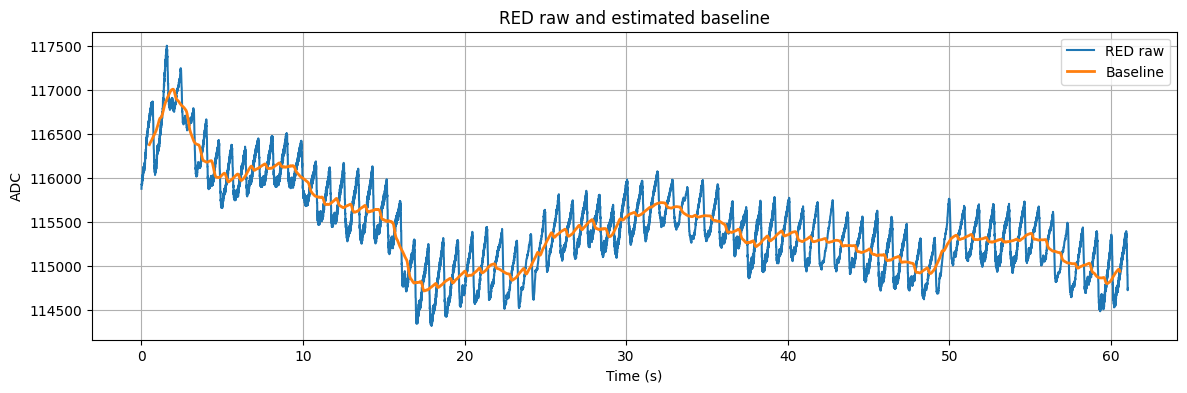

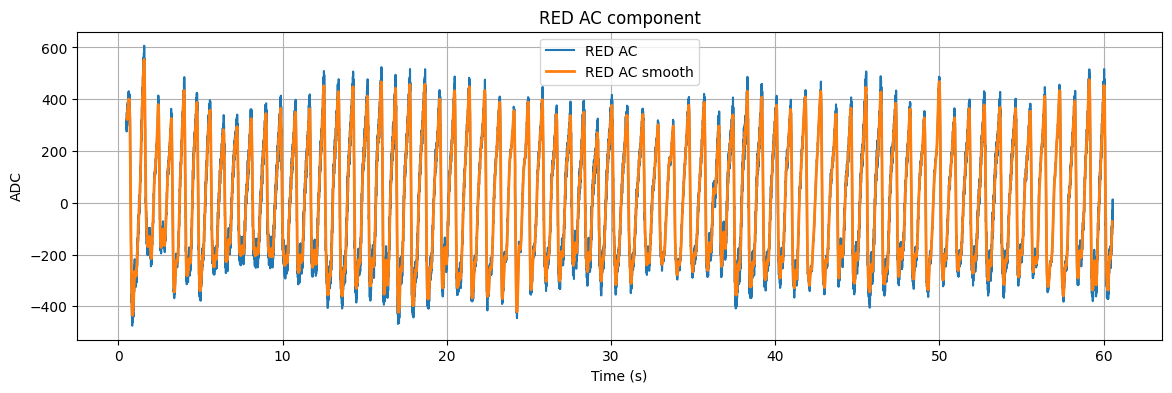

Number of peaks: 68
Estimated BPM: 68.76261503198658
Mean peak interval (s): 0.8725671641791045


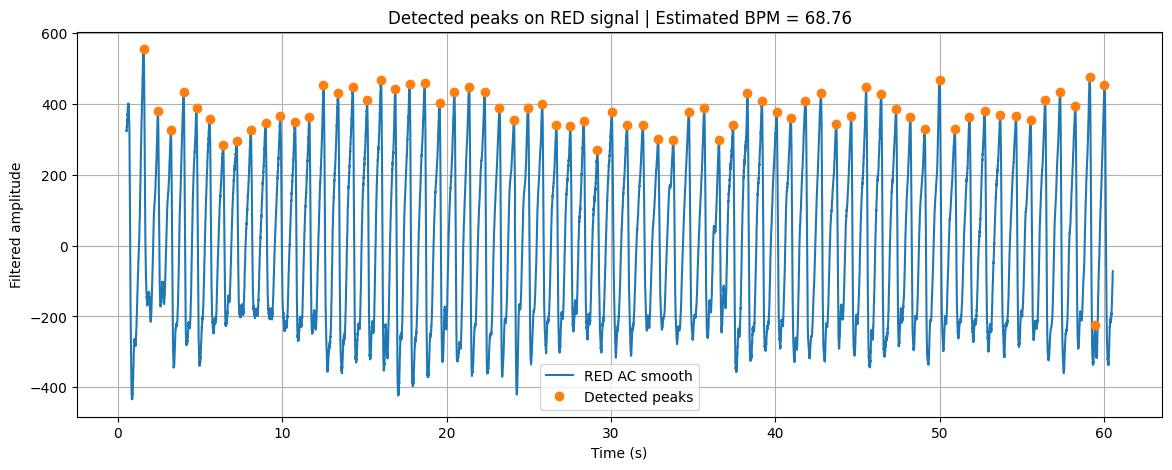

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# Đường dẫn file log của bạn
file_path = "max30102_sample_avg_1_60s.txt"

rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        parts = line.split(",")
        if len(parts) == 3:
            try:
                t = int(parts[0])
                red = int(parts[1])
                ir = int(parts[2])
                rows.append([t, red, ir])
            except ValueError:
                pass

# Tạo DataFrame
df = pd.DataFrame(rows, columns=["time_ms", "red", "ir"])
df["time_s"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0

# 1. Tính tần số lấy mẫu thực tế (fs)
dt = df["time_s"].diff().dropna()
fs = 1.0 / dt.mean()
print("Estimated sampling frequency (Hz):", fs)

# CHUYỂN ĐỔI: Sử dụng cột 'red' làm tín hiệu chính
signal = df["red"].astype(float)

# 2. Trích xuất Baseline (Thành phần DC) - Cửa sổ 1 giây
baseline_window = int(fs * 1.0)
if baseline_window < 3:
    baseline_window = 3

df["red_baseline"] = signal.rolling(window=baseline_window, center=True).mean()

# 3. Tách thành phần AC (Loại bỏ DC)
df["red_ac"] = signal - df["red_baseline"]

# 4. Làm mượt tín hiệu AC (Smoothing) - Cửa sổ 80ms
smooth_window = int(fs * 0.08)
if smooth_window < 3:
    smooth_window = 3
if smooth_window % 2 == 0:
    smooth_window += 1

df["red_ac_smooth"] = df["red_ac"].rolling(window=smooth_window, center=True).mean()

# --- BIỂU ĐỒ 1: Tín hiệu RED thô và Baseline ---
plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["red"], label="RED raw")
plt.plot(df["time_s"], df["red_baseline"], label="Baseline", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("RED raw and estimated baseline")
plt.legend()
plt.grid(True)
plt.show()

# --- BIỂU ĐỒ 2: Thành phần RED AC sau khi lọc ---
plt.figure(figsize=(14, 4))
plt.plot(df["time_s"], df["red_ac"], label="RED AC")
plt.plot(df["time_s"], df["red_ac_smooth"], label="RED AC smooth", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.title("RED AC component")
plt.legend()
plt.grid(True)
plt.show()

# 5. Thuật toán tìm đỉnh (Peak Detection)
valid = df["red_ac_smooth"].notna()
time_valid = df.loc[valid, "time_s"].to_numpy()
sig_valid = df.loc[valid, "red_ac_smooth"].to_numpy()

min_distance_sec = 0.33
min_distance_samples = int(min_distance_sec * fs)
prom = np.std(sig_valid) * 0.4

peaks, properties = find_peaks(
    sig_valid,
    distance=min_distance_samples,
    prominence=prom
)

peak_times = time_valid[peaks]
peak_values = sig_valid[peaks]

print("Number of peaks:", len(peaks))

# 6. Tính toán BPM
peak_intervals = np.diff(peak_times)

if len(peak_intervals) > 0:
    mean_interval = peak_intervals.mean()
    bpm = 60.0 / mean_interval
    print("Estimated BPM:", bpm)
    print("Mean peak interval (s):", mean_interval)
else:
    bpm = np.nan
    print("Not enough peaks to estimate BPM")

# --- BIỂU ĐỒ 3: Kết quả tìm đỉnh và nhịp tim ---
plt.figure(figsize=(14, 5))
plt.plot(time_valid, sig_valid, label="RED AC smooth")
plt.plot(peak_times, peak_values, "o", label="Detected peaks")
plt.xlabel("Time (s)")
plt.ylabel("Filtered amplitude")
plt.title(f"Detected peaks on RED signal | Estimated BPM = {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()